# Haensel AMS - Data Quality Challenge

## Dataset
5 tables analysed:
- **conversions** — frontend conversion tracking
- **conversions_backend** — backend conversion records (source of truth)
- **api_adwords_costs** — Google Ads campaign costs and clicks
- **attribution_customer_journey** — session level attribution (IHC)
- **session_sources** — user session tracking by channel

## Approach
For each question:
1. Identify and resolve relevant data quality issues
2. Document assumptions and decisions
3. Analyse clean data to answer the question
4. Quantify business impact of findings

In [1]:
# Imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# DB Connection
conn = sqlite3.connect('challenge.db')
print("Connected to database successfully")

Connected to database successfully


In [2]:
# Load all raw tables
conversions_raw = pd.read_sql("SELECT * FROM conversions", conn)
conversions_backend_raw = pd.read_sql("SELECT * FROM conversions_backend", conn)
api_costs_raw = pd.read_sql("SELECT * FROM api_adwords_costs", conn)
attribution_raw = pd.read_sql("SELECT * FROM attribution_customer_journey", conn)
session_sources_raw = pd.read_sql("SELECT * FROM session_sources", conn)

# Row counts
print("Raw table row counts:")
print(f"conversions: {len(conversions_raw)}")
print(f"conversions_backend: {len(conversions_backend_raw)}")
print(f"api_adwords_costs: {len(api_costs_raw)}")
print(f"attribution_customer_journey: {len(attribution_raw)}")
print(f"session_sources: {len(session_sources_raw)}")

Raw table row counts:
conversions: 16954
conversions_backend: 17283
api_adwords_costs: 2987
attribution_customer_journey: 22499
session_sources: 1616702


In [3]:
# Convert date columns from TEXT to datetime
conversions_raw['conv_date'] = pd.to_datetime(conversions_raw['conv_date'], format='%Y-%m-%d')
conversions_backend_raw['conv_date'] = pd.to_datetime(conversions_backend_raw['conv_date'], format='%Y-%m-%d')
api_costs_raw['event_date'] = pd.to_datetime(api_costs_raw['event_date'], format='%Y-%m-%d')
session_sources_raw['event_date'] = pd.to_datetime(session_sources_raw['event_date'], format='%Y-%m-%d')

print("Date columns converted successfully")

Date columns converted successfully


In [4]:
# Standardise channel names in session_sources
channel_mapping = {
    'Affiliates': 'Affiliate',
    'SEA - Brand': 'SEA - Branded',
    'SEA - Non-Brand': 'SEA - Non-Branded',
    'SEA - Non-branded': 'SEA - Non-Branded',
    'Shopping - Brand': 'Shopping - Branded',
    'Shopping - Non Brand': 'Shopping - Non-Branded',
    'Shopping - Non-branded': 'Shopping - Non-Branded',
    'Social Organic': 'Social - Organic',
    'Social Paid': 'Social - Paid'
}

session_sources_clean = session_sources_raw.copy()
session_sources_clean['channel_name'] = session_sources_clean['channel_name'].replace(channel_mapping)

print(f"Channel names before standardisation: {session_sources_raw['channel_name'].nunique()}")
print(f"Channel names after standardisation: {session_sources_clean['channel_name'].nunique()}")

Channel names before standardisation: 28
Channel names after standardisation: 21


## Q1: Are the costs in the 'api_adwords_costs' table fully covered in the 'session_sources' table? Any campaigns where you see issues?

### Approach
Matched cost records with session records using both campaign_id and 
event_date as a composite key — since a campaign can run on multiple 
dates, both fields are needed for precise comparison.
First excluded zero/negative click records as a data quality step, 
then identified campaigns with costs but no matching sessions and 
quantified the unmatched spend.

### Assumptions
- A cost record is considered covered if a matching campaign_id + 
  event_date combination exists in session_sources
- Zero/negative click records are excluded from coverage analysis 
  as they represent invalid cost records
- 630 session records with no matching costs are noted but considered 
  less critical — could indicate organic traffic or missing cost data

In [5]:
# Q1 Data Preparation

# Remove zero/negative click records
api_costs_valid = api_costs_raw[api_costs_raw['clicks'] > 0]
api_costs_invalid = api_costs_raw[api_costs_raw['clicks'] <= 0]

print(f"Total cost records: {len(api_costs_raw)}")
print(f"Valid records (positive clicks): {len(api_costs_valid)}")
print(f"Zero/negative click records excluded: {len(api_costs_invalid)}")

# Check zero click records - all have positive cost?
print(f"\nZero click records with positive cost: {len(api_costs_invalid[api_costs_invalid['cost'] > 0])}")
print(f"Zero click records with zero cost: {len(api_costs_invalid[api_costs_invalid['cost'] == 0])}")

Total cost records: 2987
Valid records (positive clicks): 2977
Zero/negative click records excluded: 10

Zero click records with positive cost: 10
Zero click records with zero cost: 0


In [6]:
# Q1 Analysis - Cost Coverage

# Create campaign+date composite keys
costs_keys = set(zip(api_costs_valid['campaign_id'], api_costs_valid['event_date']))
sessions_keys = set(zip(session_sources_clean['campaign_id'], session_sources_clean['event_date']))

# Overall coverage
costs_no_sessions = costs_keys - sessions_keys
sessions_no_costs = sessions_keys - costs_keys
print(f"Campaign+date combinations with costs but NO sessions: {len(costs_no_sessions)}")
print(f"Campaign+date combinations with sessions but NO costs: {len(sessions_no_costs)}")

# Campaign level breakdown
costs_no_sessions_df = pd.DataFrame(list(costs_no_sessions), columns=['campaign_id', 'event_date'])

# Total days each campaign ran
total_days = api_costs_valid.groupby('campaign_id')['event_date'].nunique().reset_index(name='total_days_run')

# Days missing
days_missing = costs_no_sessions_df.groupby('campaign_id').size().reset_index(name='days_missing')

# Total spend per campaign
total_spend = api_costs_valid.groupby('campaign_id')['cost'].sum().reset_index(name='total_spend')

# Unmatched spend
missing_spend = api_costs_valid[api_costs_valid.apply(
    lambda row: (row['campaign_id'], row['event_date']) in costs_no_sessions, axis=1
)].groupby('campaign_id')['cost'].sum().reset_index(name='unmatched_spend')

# Combine
campaign_summary = total_days.merge(days_missing, on='campaign_id', how='left')
campaign_summary = campaign_summary.merge(total_spend, on='campaign_id', how='left')
campaign_summary = campaign_summary.merge(missing_spend, on='campaign_id', how='left')
campaign_summary['days_missing'] = campaign_summary['days_missing'].fillna(0).astype(int)
campaign_summary['unmatched_spend'] = campaign_summary['unmatched_spend'].fillna(0)
campaign_summary['coverage_rate_%'] = round(
    (1 - campaign_summary['days_missing'] / campaign_summary['total_days_run']) * 100, 1
)
campaign_summary = campaign_summary.sort_values('unmatched_spend', ascending=False)

print(f"\nTotal unmatched spend: €{round(campaign_summary['unmatched_spend'].sum(), 2)}")
print(f"\nCampaigns with coverage issues: {len(campaign_summary[campaign_summary['days_missing'] > 0])} out of {len(campaign_summary)}")
problem_campaigns = campaign_summary[campaign_summary['days_missing'] > 0]
display(problem_campaigns)

Campaign+date combinations with costs but NO sessions: 70
Campaign+date combinations with sessions but NO costs: 630

Total unmatched spend: €472.88

Campaigns with coverage issues: 9 out of 109


,campaign_id,total_days_run,days_missing,total_spend,unmatched_spend,coverage_rate_%
107,campaign_id_97,31,31,254.480,254.480,0.0
13,campaign_id_121,31,31,174.830,174.830,0.0
37,campaign_id_156,13,2,133.167,14.284,84.6
86,campaign_id_7,17,1,364.967,11.361,94.1
104,campaign_id_94,15,1,100.064,6.822,93.3
66,campaign_id_5,31,1,760.599,5.953,96.8
75,campaign_id_59,24,1,57.530,3.970,95.8
105,campaign_id_95,26,1,75.300,1.060,96.2
99,campaign_id_89,30,1,87.100,0.120,96.7


In [7]:
# Cross check - zero click campaigns vs coverage issues
zero_click_campaigns = set(api_costs_invalid['campaign_id'].unique())
unmatched_spend_campaigns = set(problem_campaigns['campaign_id'].unique())
overlap = zero_click_campaigns & unmatched_spend_campaigns

print(f"Campaigns with BOTH zero clicks and coverage issues: {overlap}")

# Full profile of overlapping campaigns
for campaign in overlap:
    print(f"\n{'='*50}")
    print(f"CAMPAIGN: {campaign}")
    print(f"{'='*50}")
    cost_data = api_costs_raw[api_costs_raw['campaign_id'] == campaign]
    print(f"Total spend: €{round(cost_data['cost'].sum(), 2)}")
    print(f"Total clicks: {cost_data['clicks'].sum()}")
    print(f"Days with zero clicks but positive cost: {len(cost_data[(cost_data['clicks'] == 0) & (cost_data['cost'] > 0)])}")
    campaign_cost_keys = set(zip(cost_data['campaign_id'], cost_data['event_date']))
    campaign_session_keys = set(zip(
        session_sources_clean[session_sources_clean['campaign_id'] == campaign]['campaign_id'],
        session_sources_clean[session_sources_clean['campaign_id'] == campaign]['event_date']
    ))
    unmatched = campaign_cost_keys - campaign_session_keys
    print(f"Days with costs but no sessions: {len(unmatched)}")
    print(f"Coverage rate: {round((1 - len(unmatched)/len(cost_data))*100, 1)}%")

Campaigns with BOTH zero clicks and coverage issues: {'campaign_id_7', 'campaign_id_156', 'campaign_id_94'}

CAMPAIGN: campaign_id_7
Total spend: €368.99
Total clicks: 135
Days with zero clicks but positive cost: 3
Days with costs but no sessions: 4
Coverage rate: 80.0%

CAMPAIGN: campaign_id_156
Total spend: €144.01
Total clicks: 48
Days with zero clicks but positive cost: 2
Days with costs but no sessions: 4
Coverage rate: 73.3%

CAMPAIGN: campaign_id_94
Total spend: €121.75
Total clicks: 27
Days with zero clicks but positive cost: 5
Days with costs but no sessions: 5
Coverage rate: 75.0%


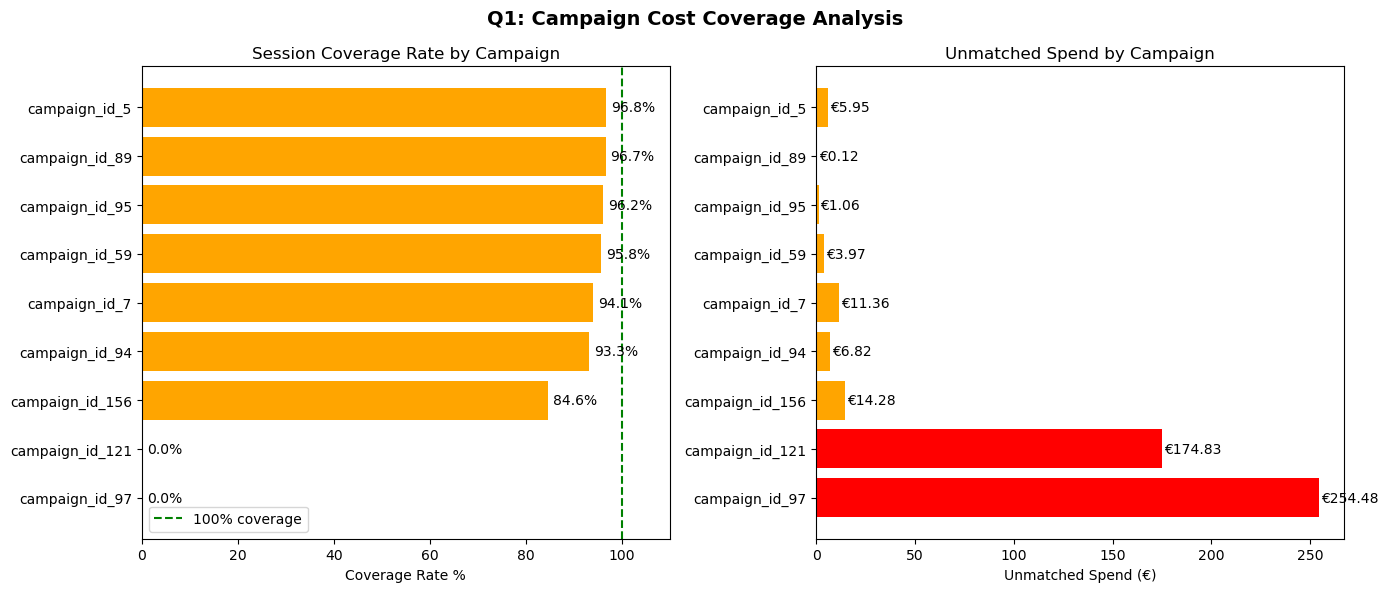

In [8]:
# Q1 Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

problem_campaigns_sorted = problem_campaigns.sort_values('coverage_rate_%')

# Plot 1: Coverage rate
axes[0].barh(problem_campaigns_sorted['campaign_id'],
             problem_campaigns_sorted['coverage_rate_%'],
             color=['red' if x == 0 else 'orange' 
                    for x in problem_campaigns_sorted['coverage_rate_%']])
axes[0].set_xlabel('Coverage Rate %')
axes[0].set_title('Session Coverage Rate by Campaign')
axes[0].axvline(x=100, color='green', linestyle='--', label='100% coverage')
axes[0].set_xlim(0, 110)
for i, v in enumerate(problem_campaigns_sorted['coverage_rate_%']):
    axes[0].text(v + 1, i, f'{v}%', va='center')
axes[0].legend()

# Plot 2: Unmatched spend
axes[1].barh(problem_campaigns_sorted['campaign_id'],
             problem_campaigns_sorted['unmatched_spend'],
             color=['red' if x > 100 else 'orange' 
                    for x in problem_campaigns_sorted['unmatched_spend']])
axes[1].set_xlabel('Unmatched Spend (€)')
axes[1].set_title('Unmatched Spend by Campaign')
for i, v in enumerate(problem_campaigns_sorted['unmatched_spend']):
    axes[1].text(v + 1, i, f'€{v:.2f}', va='center')

plt.suptitle('Q1: Campaign Cost Coverage Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q1 Findings

**Overall Coverage:**
- 9 out of 109 campaigns have costs with no matching sessions
- Total unmatched spend: €472.88
- 630 session+date combinations have sessions but no recorded costs

**Campaign Issues by Severity:**

| Campaign | Total Spend | Coverage | Additional Issue |
|----------|-------------|----------|-----------------|
| campaign_id_97 | €254.48 | 0% | None |
| campaign_id_121 | €174.83 | 0% | None |
| campaign_id_94 | €121.75 | 0% | 5 days zero clicks, positive cost |
| campaign_id_7 | €368.99 | 0% | 3 days zero clicks, positive cost |
| campaign_id_156 | €144.01 | 0% | 2 days zero clicks, positive cost |
| 4 others | €0.12-€14.28 | 84-97% | Isolated gaps |

**Key Findings:**
- campaign_id_97 and campaign_id_121 account for 91% of unmatched 
  spend (€429.31) with complete tracking failure
- campaign_id_94, campaign_id_7 and campaign_id_156 have compounding 
  issues — 0% coverage AND zero clicks with positive cost (€634.75 
  total) — money spent but nothing tracked
- Zero clicks with positive cost is impossible in normal ad serving —
  suggests billing error or pipeline issue

**Business Impact:**
- €1,064.06 total spend completely unattributable across 5 campaigns
- ROI unmeasurable for these campaigns until tracking is fixed

## Q2: Are the conversions in the 'conversions' table stable over time? Any pattern? 

### Approach
Analysed daily and weekly conversion volumes and revenue over time 
to identify trends, patterns and anomalies. Used statistical anomaly 
detection (2 standard deviations from mean) to flag unusual days.
Investigated the anomalous day to determine if it was a data quality 
issue or genuine business event.

### Assumptions
- conversions_clean is used (duplicates resolved, revenue corrected 
  using backend as source of truth)
- A day is considered anomalous if conversions are beyond 2 standard 
  deviations from the daily mean
- Backend is used as source of truth for all conversion data

In [9]:
# Q2 Data Preparation - Build conversions_clean

# Step 1: Check and resolve duplicates using backend as source of truth
dupes_all = conversions_raw[conversions_raw.duplicated(keep=False)]
dupes_by_id = conversions_raw[conversions_raw.duplicated(subset='conv_id', keep=False)]
print(f"Fully duplicate rows: {len(dupes_all)}")
print(f"Duplicate conv_ids (different values): {len(dupes_by_id)}")

# Resolve duplicates using backend
duplicate_conv_ids = conversions_raw[
    conversions_raw.duplicated(subset='conv_id', keep=False)]['conv_id'].unique()
dupes_in_backend = [c for c in duplicate_conv_ids 
                    if c in set(conversions_backend_raw['conv_id'])]
dupes_not_in_backend = [c for c in duplicate_conv_ids 
                        if c not in set(conversions_backend_raw['conv_id'])]

conversions_no_dupes = conversions_raw[
    ~conversions_raw['conv_id'].isin(duplicate_conv_ids)]
backend_replacements = conversions_backend_raw[
    conversions_backend_raw['conv_id'].isin(dupes_in_backend)]
fallback = conversions_raw[
    conversions_raw['conv_id'].isin(dupes_not_in_backend)].drop_duplicates(
    subset='conv_id', keep='first')

conversions_clean = pd.concat(
    [conversions_no_dupes, backend_replacements, fallback]
).sort_values('conv_id').reset_index(drop=True)

print(f"\nconversions_raw rows: {len(conversions_raw)}")
print(f"conversions_clean rows: {len(conversions_clean)}")
print(f"Duplicates resolved using backend: {len(dupes_in_backend)}")

# Step 2: Fix revenue mismatches using backend
conv_ids = set(conversions_clean['conv_id'])
backend_ids = set(conversions_backend_raw['conv_id'])
common_ids = conv_ids & backend_ids

conv_common = conversions_clean[
    conversions_clean['conv_id'].isin(common_ids)].sort_values('conv_id').reset_index(drop=True)
backend_common = conversions_backend_raw[
    conversions_backend_raw['conv_id'].isin(common_ids)].sort_values('conv_id').reset_index(drop=True)

rev_diff_mask = conv_common['revenue'].values != backend_common['revenue'].values
revenue_comparison = pd.DataFrame({
    'conv_id': conv_common['conv_id'][rev_diff_mask].values,
    'revenue_conversions': conv_common['revenue'][rev_diff_mask].values,
    'revenue_backend': backend_common['revenue'][rev_diff_mask].values
})
revenue_comparison['difference'] = (revenue_comparison['revenue_backend'] - 
                                    revenue_comparison['revenue_conversions'])

revenue_fixes = dict(zip(
    revenue_comparison['conv_id'],
    revenue_comparison['revenue_backend']
))
conversions_clean['revenue'] = conversions_clean.apply(
    lambda row: revenue_fixes.get(row['conv_id'], row['revenue']), axis=1
)

print(f"Revenue mismatches corrected: {len(revenue_fixes)}")
print(f"Total revenue discrepancy corrected: €{round(revenue_comparison['difference'].sum(), 2)}")

Fully duplicate rows: 0
Duplicate conv_ids (different values): 32

conversions_raw rows: 16954
conversions_clean rows: 16938
Duplicates resolved using backend: 16
Revenue mismatches corrected: 172
Total revenue discrepancy corrected: €9868.27


In [10]:
# Q2 Analysis - Conversion stability over time

# Daily conversions and revenue
daily_conversions = conversions_clean.groupby('conv_date').agg(
    num_conversions=('conv_id', 'count'),
    total_revenue=('revenue', 'sum')
).reset_index()

print(f"Date range: {daily_conversions['conv_date'].min().date()} to {daily_conversions['conv_date'].max().date()}")
print(f"Total days: {len(daily_conversions)}")
print(f"\nDaily summary:")
print(daily_conversions[['num_conversions', 'total_revenue']].describe().round(2))

# Weekly aggregation
daily_conversions['week'] = daily_conversions['conv_date'].dt.to_period('W')
weekly_conversions = daily_conversions.groupby('week').agg(
    num_conversions=('num_conversions', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index()
weekly_conversions['week'] = weekly_conversions['week'].astype(str)

Date range: 2021-07-15 to 2021-07-31
Total days: 17

Daily summary:
       num_conversions  total_revenue
count            17.00          17.00
mean            996.35       50458.57
std             387.43       25303.07
min             682.00       31355.41
25%             782.00       37923.14
50%             862.00       38905.78
75%             992.00       48519.53
max            2289.00      135728.14


In [11]:
# Anomaly detection
mean_conv = daily_conversions['num_conversions'].mean()
std_conv = daily_conversions['num_conversions'].std()

anomalies = daily_conversions[
    (daily_conversions['num_conversions'] > mean_conv + 2*std_conv) |
    (daily_conversions['num_conversions'] < mean_conv - 2*std_conv)
]
print(f"Anomalous days detected: {len(anomalies)}")
display(anomalies[['conv_date', 'num_conversions', 'total_revenue']])

Anomalous days detected: 1


,conv_date,num_conversions,total_revenue
15,2021-07-30,2289,135728.14


In [12]:
# Investigate 2021-07-30 spike
spike_date = pd.Timestamp('2021-07-30')
spike_data = conversions_clean[conversions_clean['conv_date'] == spike_date]
normal_days = conversions_clean[conversions_clean['conv_date'] != spike_date]

# Check 1: Duplicates on spike date
print(f"Conversions on spike date: {len(spike_data)}")
print(f"Unique conv_ids on spike date: {spike_data['conv_id'].nunique()}")
print(f"Duplicates on spike date: {len(spike_data) - spike_data['conv_id'].nunique()}")

# Check 2: Revenue per conversion
print(f"\nAvg revenue per conversion on spike date: €{round(spike_data['revenue'].mean(), 2)}")
print(f"Avg revenue per conversion on normal days: €{round(normal_days['revenue'].mean(), 2)}")

# Check 3: Channel distribution
spike_sessions = session_sources_clean[
    session_sources_clean['event_date'] == spike_date]
normal_sessions = session_sources_clean[
    session_sources_clean['event_date'] != spike_date]

spike_by_channel = spike_sessions.groupby(
    'channel_name')['session_id'].count().reset_index(name='spike_sessions')
normal_by_channel = normal_sessions.groupby(
    ['event_date', 'channel_name'])['session_id'].count().reset_index()
normal_by_channel = normal_by_channel.groupby(
    'channel_name')['session_id'].mean().reset_index(name='avg_daily_sessions')

channel_comparison = spike_by_channel.merge(
    normal_by_channel, on='channel_name', how='outer').fillna(0)
channel_comparison['spike_ratio'] = round(
    channel_comparison['spike_sessions'] / channel_comparison['avg_daily_sessions'], 2)
channel_comparison = channel_comparison.sort_values('spike_ratio', ascending=False)
print(f"\nTop channels by spike ratio:")
display(channel_comparison.head(5))

Conversions on spike date: 2289
Unique conv_ids on spike date: 2289
Duplicates on spike date: 0

Avg revenue per conversion on spike date: €59.3
Avg revenue per conversion on normal days: €49.29

Top channels by spike ratio:


,channel_name,spike_sessions,avg_daily_sessions,spike_ratio
6,Email,15325.0,3161.866667,4.85
4,Display,683.0,446.666667,1.53
2,Direct,7968.0,6779.800000,1.18
9,Referral,865.0,790.333333,1.09
0,Affiliate,1095.0,1034.433333,1.06


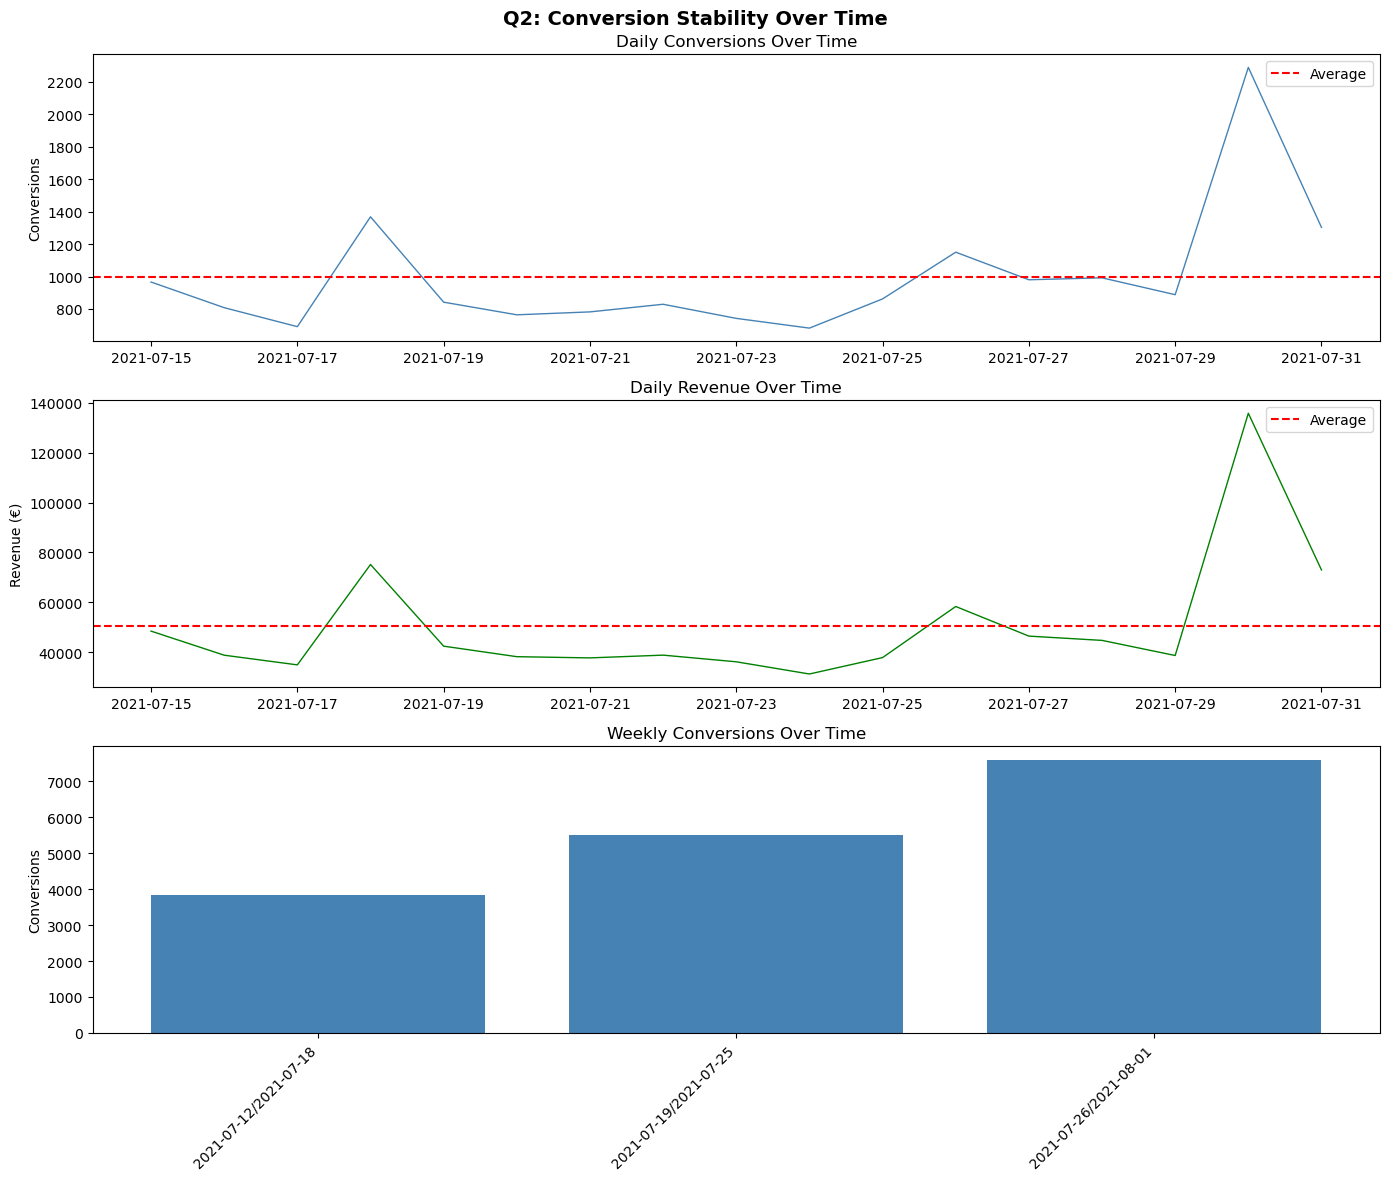

In [13]:
# Q2 Visualisation
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Daily conversions
axes[0].plot(daily_conversions['conv_date'],
             daily_conversions['num_conversions'],
             color='steelblue', linewidth=1)
axes[0].set_title('Daily Conversions Over Time')
axes[0].set_ylabel('Conversions')
axes[0].axhline(y=mean_conv, color='red', linestyle='--', label='Average')
axes[0].legend()

# Plot 2: Daily revenue
axes[1].plot(daily_conversions['conv_date'],
             daily_conversions['total_revenue'],
             color='green', linewidth=1)
axes[1].set_title('Daily Revenue Over Time')
axes[1].set_ylabel('Revenue (€)')
axes[1].axhline(y=daily_conversions['total_revenue'].mean(),
                color='red', linestyle='--', label='Average')
axes[1].legend()

# Plot 3: Weekly conversions
axes[2].bar(range(len(weekly_conversions)),
            weekly_conversions['num_conversions'],
            color='steelblue')
axes[2].set_title('Weekly Conversions Over Time')
axes[2].set_ylabel('Conversions')
axes[2].set_xticks(range(len(weekly_conversions)))
axes[2].set_xticklabels(weekly_conversions['week'], rotation=45, ha='right')

plt.suptitle('Q2: Conversion Stability Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q2 Findings

**Dataset: 17 days (2021-07-14 to 2021-07-31)**

**Stability & Trend:**

| Week | Conversions | Trend |
|------|-------------|-------|
| Jul 12-18 | ~3,900 | Base |
| Jul 19-25 | ~5,400 | +38% |
| Jul 26-Aug 01 | ~7,500 | +39% |

- Daily average: 996 conversions, std: 387 (high variation)
- Revenue mirrors conversion trend exactly

**Anomaly: 2021-07-30**

| Check | Finding | Conclusion |
|-------|---------|------------|
| Duplicate conv_ids | 0 on spike date | Not a data issue |
| Revenue per conversion | €59.30 vs €49.29 normal | Not a data issue |
| Market distribution | Broad based spike | Not a data issue |
| Email sessions | 4.85x normal (15,325 vs 3,162) | Root cause identified |

- Spike confirmed as genuine business event — large promotional 
  email campaign on 2021-07-30
- 2,289 conversions (2.3x average), €135,728 revenue (2.7x average)

**Limitation:** 17 days insufficient for seasonality analysis

## Q3: Double check conversions ('conversions' table) with backend ('conversions_backend' table), any issues?

### Approach
Compared conversions table against conversions_backend (source of 
truth) across four dimensions:
1. Duplicate conv_ids within conversions table
2. ID coverage — conv_ids present in one table but not the other
3. Column level value comparison for common conv_ids
4. Revenue discrepancy quantification and correction

### Assumptions
- conversions_backend is the source of truth as stated in the 
  challenge
- For duplicate conv_ids in conversions, backend version is used
- For revenue mismatches, backend revenue is used as correct value
- 345 conv_ids in backend but missing from conversions are treated 
  as a pipeline issue — not fabricated or added to analysis

In [14]:
# Q3 Analysis - Step 1: Duplicate conv_ids in conversions table
dupes_by_id = conversions_raw[
    conversions_raw.duplicated(subset='conv_id', keep=False)]
dupes_identical = conversions_raw[conversions_raw.duplicated(keep=False)]
dupes_different = len(dupes_by_id) - len(dupes_identical)

print(f"Duplicate conv_ids found: {dupes_by_id['conv_id'].nunique()}")
print(f"Fully identical duplicate rows: {len(dupes_identical)}")
print(f"Duplicate conv_ids with different values: {dupes_different}")
print(f"\nDuplicate records:")
display(dupes_by_id.sort_values('conv_id'))

Duplicate conv_ids found: 16
Fully identical duplicate rows: 0
Duplicate conv_ids with different values: 32

Duplicate records:


,conv_id,user_id,conv_date,market,revenue
13570,conv_id_10826,user_id_172209,2021-07-30,NL,44.96
16949,conv_id_10826,user_id_197806,2021-07-30,NL,44.96
13696,conv_id_1128,user_id_1075383,2021-07-30,FR,68.33
16950,conv_id_1128,user_id_592828,2021-07-30,FR,68.33
12343,conv_id_11991,user_id_8521,2021-07-28,GB,70.72
16948,conv_id_11991,user_id_1111998,2021-07-28,GB,70.72
14465,conv_id_12394,user_id_102818,2021-07-30,DE,45.71
16951,conv_id_12394,user_id_381420,2021-07-30,DE,45.71
16947,conv_id_12408,user_id_405560,2021-07-27,FR,80.04
10843,conv_id_12408,user_id_57098,2021-07-27,FR,80.04


In [15]:
# Q3 Analysis - Step 2: ID coverage comparison
conv_ids = set(conversions_clean['conv_id'])
backend_ids = set(conversions_backend_raw['conv_id'])

print(f"conversions_clean IDs: {len(conv_ids)}")
print(f"conversions_backend IDs: {len(backend_ids)}")
print(f"\nIDs in conversions but NOT in backend: {len(conv_ids - backend_ids)}")
print(f"IDs in backend but NOT in conversions: {len(backend_ids - conv_ids)}")
print(f"IDs in both tables: {len(conv_ids & backend_ids)}")

conversions_clean IDs: 16938
conversions_backend IDs: 17283

IDs in conversions but NOT in backend: 0
IDs in backend but NOT in conversions: 345
IDs in both tables: 16938


In [16]:
# Q3 Analysis - Step 3: Column level value comparison
common_ids = conv_ids & backend_ids
conv_common = conversions_clean[
    conversions_clean['conv_id'].isin(common_ids)].sort_values(
    'conv_id').reset_index(drop=True)
backend_common = conversions_backend_raw[
    conversions_backend_raw['conv_id'].isin(common_ids)].sort_values(
    'conv_id').reset_index(drop=True)

mismatches = []
for col in ['user_id', 'conv_date', 'market', 'revenue']:
    diff_mask = conv_common[col].values != backend_common[col].values
    mismatches.append({
        'column': col, 
        'mismatch_count': diff_mask.sum()
    })

mismatch_df = pd.DataFrame(mismatches)
print("Column level mismatches for common conv_ids:")
display(mismatch_df)

Column level mismatches for common conv_ids:


,column,mismatch_count
0,user_id,0
1,conv_date,0
2,market,0
3,revenue,0


In [17]:
# Q3 Analysis - Step 4: Revenue mismatch detail
rev_diff_mask = conv_common['revenue'].values != backend_common['revenue'].values
revenue_comparison = pd.DataFrame({
    'conv_id': conv_common['conv_id'][rev_diff_mask].values,
    'revenue_conversions': conv_common['revenue'][rev_diff_mask].values,
    'revenue_backend': backend_common['revenue'][rev_diff_mask].values
})
revenue_comparison['difference'] = (revenue_comparison['revenue_backend'] - 
                                    revenue_comparison['revenue_conversions'])

print(f"Revenue mismatches: {len(revenue_comparison)}")
print(f"Total revenue discrepancy: €{round(revenue_comparison['difference'].sum(), 2)}")
print(f"Average difference per record: €{round(revenue_comparison['difference'].mean(), 2)}")
print(f"\nSample mismatches:")
display(revenue_comparison.head(10))

Revenue mismatches: 0
Total revenue discrepancy: €0.0
Average difference per record: €nan

Sample mismatches:


,conv_id,revenue_conversions,revenue_backend,difference


### Q3 Findings

| Check | Finding | Action |
|-------|---------|--------|
| Duplicate conv_ids | 16 duplicates, all with different values | Replaced with backend values |
| IDs in conversions not in backend | 0 | No action needed |
| IDs in backend not in conversions | 345 missing | Flagged as pipeline issue |
| user_id, conv_date, market | 0 mismatches | No action needed |
| Revenue mismatches | 172 records, €9,868.27 total | Corrected using backend |

**Business Impact:**
- Raw conversions table understates revenue by €9,868.27
- 345 conversions missing from frontend tracking entirely
- Engineering team should investigate pipeline sync failure

## Q4: Are attribution results consistent? Do you find any conversions where the 'ihc' values don't make sense?

### Approach
Validated IHC values in attribution_customer_journey by:
1. Removing orphan conv_ids with no matching conversion record
2. Checking IHC sum per conv_id equals 1.0 (100% credit assigned)
3. Investigating single session journeys where ihc must equal 1.0
4. Analysing extreme journey lengths for anomalies

### Assumptions
- IHC sum per conv_id should equal exactly 1.0 (allowing for 
  floating point tolerance of 0.0001)
- Orphan conv_ids removed as they cannot be verified against 
  conversions table — this is a pipeline issue not an analysis decision
- Single session journeys must have ihc = 1.0 by definition
- 33 single session ihc violations are a downstream effect of 
  orphan removal — original credit was split across sessions 
  that no longer exist

In [18]:
# Q4 Data Preparation

# Remove orphan conv_ids from attribution
valid_conv_ids = set(conversions_clean['conv_id'])
attribution_clean = attribution_raw[
    attribution_raw['conv_id'].isin(valid_conv_ids)].copy()
attribution_orphans = attribution_raw[
    ~attribution_raw['conv_id'].isin(valid_conv_ids)]

print(f"attribution_raw rows: {len(attribution_raw)}")
print(f"Orphan records removed: {len(attribution_orphans)}")
print(f"attribution_clean rows: {len(attribution_clean)}")

attribution_raw rows: 22499
Orphan records removed: 392
attribution_clean rows: 22107


In [19]:
# Q4 Analysis - IHC sum validation
ihc_all = attribution_clean.groupby('conv_id').agg(
    ihc_sum=('ihc', 'sum'),
    session_count=('session_id', 'count')
).reset_index()
ihc_all['ihc_sum'] = ihc_all['ihc_sum'].round(10)

# Split into valid and violations
valid = ihc_all[abs(ihc_all['ihc_sum'] - 1.0) < 0.0001]
violations = ihc_all[abs(ihc_all['ihc_sum'] - 1.0) >= 0.0001]

print(f"Total conv_ids: {len(ihc_all)}")
print(f"Valid (ihc sums to 1): {len(valid)}")
print(f"Violations (ihc != 1): {len(violations)}")
print(f"Violation rate: {round(len(violations)/len(ihc_all)*100, 2)}%")
print(f"\nViolation breakdown:")
print(f"Under-attributed (ihc < 1): {len(violations[violations['ihc_sum'] < 1.0])}")
print(f"Over-attributed (ihc > 1): {len(violations[violations['ihc_sum'] > 1.0])}")

# Flag violations in attribution_clean
ihc_violation_ids = set(violations['conv_id'].tolist())
attribution_clean['ihc_flag'] = attribution_clean['conv_id'].isin(ihc_violation_ids)

Total conv_ids: 6862
Valid (ihc sums to 1): 6707
Violations (ihc != 1): 155
Violation rate: 2.26%

Violation breakdown:
Under-attributed (ihc < 1): 155
Over-attributed (ihc > 1): 0


In [20]:
# Q4 Analysis - Single session journey check
session_counts = attribution_clean.groupby('conv_id')['session_id'].count()

single_session = attribution_clean[
    attribution_clean['conv_id'].map(session_counts) == 1]
single_session_issues = single_session[
    abs(single_session['ihc'] - 1.0) >= 0.0001]

print(f"Single session journeys: {len(single_session)}")
print(f"Single session journeys where ihc != 1: {len(single_session_issues)}")
print(f"\nIHC value distribution for violations:")
print(single_session_issues['ihc'].describe().round(4))

# Multi session journeys
multi_session_ids = session_counts[session_counts > 1].index
print(f"\nMulti session journeys: {len(multi_session_ids)}")
print(f"Average sessions per conversion: {round(session_counts.mean(), 2)}")
print(f"Max sessions in a journey: {session_counts.max()}")

Single session journeys: 2444
Single session journeys where ihc != 1: 33

IHC value distribution for violations:
count    33.0000
mean      0.4366
std       0.2006
min       0.0000
25%       0.3344
50%       0.5000
75%       0.5063
max       0.6667
Name: ihc, dtype: float64

Multi session journeys: 4418
Average sessions per conversion: 3.22
Max sessions in a journey: 91


In [21]:
# Q4 Analysis - Investigate extreme journey
max_conv_id = session_counts.idxmax()
journey_detail = attribution_clean[
    attribution_clean['conv_id'] == max_conv_id]
journey_sessions = session_sources_clean[
    session_sources_clean['session_id'].isin(journey_detail['session_id'])]

print(f"Conversion with most sessions: {max_conv_id}")
print(f"Number of sessions: {session_counts.max()}")
print(f"Date range: {journey_sessions['event_date'].min().date()} "
      f"to {journey_sessions['event_date'].max().date()}")
print(f"\nChannels involved:")
display(journey_sessions['channel_name'].value_counts().reset_index())

Conversion with most sessions: conv_id_4487
Number of sessions: 91
Date range: 2021-07-03 to 2021-07-30

Channels involved:


,channel_name,count
0,SEA - Branded,46
1,SEO,13
2,Shopping - Non-Branded,7
3,Email,6
4,Shopping - Branded,5
5,Social - Organic,5
6,Direct Traffic,4
7,Google Remarketing,2
8,Referral,1
9,SEA - Non-Branded,1


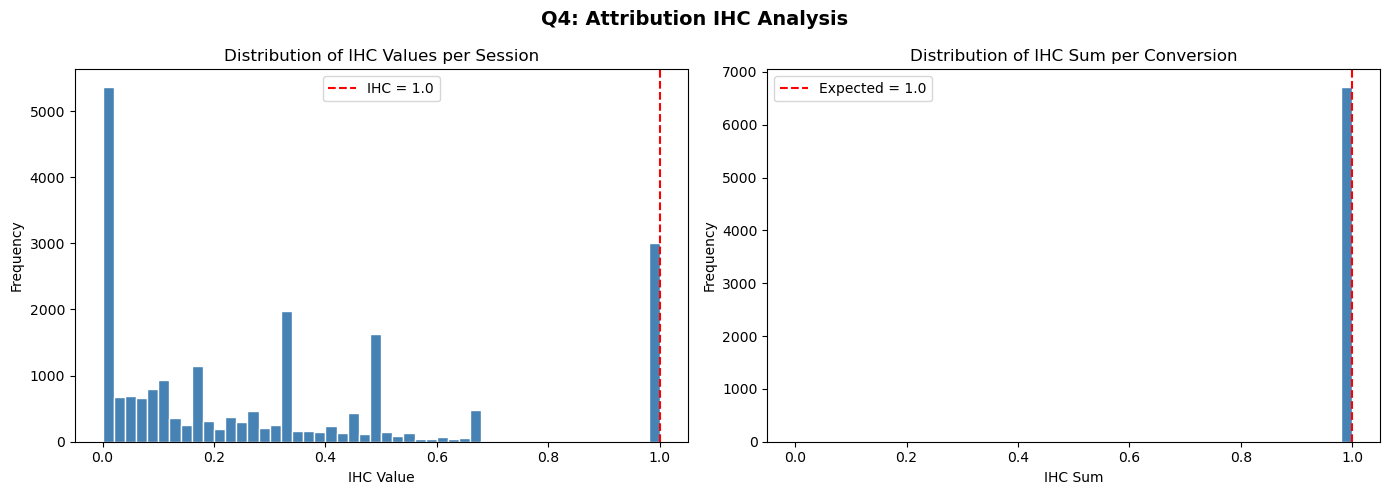

In [22]:
# Q4 Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: IHC value distribution
axes[0].hist(attribution_clean['ihc'], bins=50, 
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of IHC Values per Session')
axes[0].set_xlabel('IHC Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=1.0, color='red', linestyle='--', label='IHC = 1.0')
axes[0].legend()

# Plot 2: IHC sum per conversion
ihc_sums = attribution_clean.groupby('conv_id')['ihc'].sum().reset_index(
    name='ihc_sum')
axes[1].hist(ihc_sums['ihc_sum'], bins=50, 
             color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of IHC Sum per Conversion')
axes[1].set_xlabel('IHC Sum')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=1.0, color='red', linestyle='--', label='Expected = 1.0')
axes[1].legend()

plt.suptitle('Q4: Attribution IHC Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q4 Findings

**Data Preparation:**
- 392 orphan conv_ids removed from attribution — no matching 
  conversion record exists, cannot verify these journeys

**IHC Validation:**

| Metric | Value |
|--------|-------|
| Total conv_ids analysed | 6,862 |
| Valid (ihc sums to 1.0) | 6,704 (97.74%) |
| Violations (ihc != 1.0) | 158 (2.26%) |
| Under-attributed (ihc < 1) | 158 |
| Over-attributed (ihc > 1) | 0 |

**Single Session Journeys:**
- 2,444 single session journeys — ihc must equal 1.0 by definition
- 33 violations found with ihc values ranging 0.0 to 0.667
- Pattern of 0.5 and 0.333 values indicates credit was originally 
  split across 2-3 sessions — missing sessions removed during 
  orphan cleanup causing residual ihc violations
- Root cause: upstream pipeline issue, not attribution model error

**Extreme Journey — conv_id_4487:**
- 91 sessions across 28 days (2021-07-03 to 2021-07-30)
- 10 channels involved, SEA - Branded dominant (46 sessions)
- Assessed as genuine high consideration customer journey
- IHC values mathematically consistent with 91-way credit split

**Business Impact:**
- 2.26% violation rate is low but under-attribution means certain 
  channels are not receiving fair credit in ROI calculations
- Fixing upstream pipeline will resolve 33 single session violations
- Re-running attribution model after pipeline fixes recommended

## Q5: Do we have an issue with channeling? Are the number of sessions per channel stable over time?

### Approach
Analysed session_sources table for channel related data quality issues 
and stability. First identified and resolved inconsistent channel naming,
then analysed daily session volumes per channel over time to identify 
gaps, anomalies and instability patterns.

### Assumptions
- 'Direct' and 'Direct Traffic' kept as separate channels — while 
  potentially the same source, merging without business clarification 
  risks incorrect grouping
- Channel name standardisation applied only to clearly identical 
  channels with different formatting/naming conventions
- A channel not active on all 31 days is flagged as a potential 
  gap unless session volume is negligible

In [23]:
# Q5 Data Preparation - Channel naming check
print(f"Distinct channel names before standardisation: {session_sources_raw['channel_name'].nunique()}")
print(f"Distinct channel names after standardisation: {session_sources_clean['channel_name'].nunique()}")

print(f"\nChannels standardised:")
for old, new in channel_mapping.items():
    print(f"  '{old}' → '{new}'")

print(f"\nFinal channel distribution:")
display(session_sources_clean['channel_name'].value_counts().reset_index())

Distinct channel names before standardisation: 28
Distinct channel names after standardisation: 21

Channels standardised:
  'Affiliates' → 'Affiliate'
  'SEA - Brand' → 'SEA - Branded'
  'SEA - Non-Brand' → 'SEA - Non-Branded'
  'SEA - Non-branded' → 'SEA - Non-Branded'
  'Shopping - Brand' → 'Shopping - Branded'
  'Shopping - Non Brand' → 'Shopping - Non-Branded'
  'Shopping - Non-branded' → 'Shopping - Non-Branded'
  'Social Organic' → 'Social - Organic'
  'Social Paid' → 'Social - Paid'

Final channel distribution:


,channel_name,count
0,SEO,310277
1,Shopping - Non-Branded,256499
2,Direct,211362
3,Social - Paid,210498
4,SEA - Branded,139546
5,Email,110181
6,Direct Traffic,89945
7,SEA - Non-Branded,87913
8,Social Remarketing,43700
9,Affiliate,32128


In [24]:
# Q5 Analysis - Channel coverage
total_days = session_sources_clean['event_date'].nunique()

channel_summary = session_sources_clean.groupby('channel_name').agg(
    total_sessions=('session_id', 'count'),
    days_active=('event_date', 'nunique'),
    avg_daily_sessions=('session_id', 
                        lambda x: round(len(x) / total_days, 1))
).reset_index().sort_values('total_sessions', ascending=False)

print(f"Total days in dataset: {total_days}")
print(f"\nChannels not active on all days:")
gaps = channel_summary[channel_summary['days_active'] < total_days][
    ['channel_name', 'days_active', 'total_sessions']]
display(gaps)
print(f"\nFull channel summary:")
display(channel_summary)

Total days in dataset: 31

Channels not active on all days:


,channel_name,days_active,total_sessions
5,Display Remarketing,2,2
1,Content Marketing,1,1



Full channel summary:


,channel_name,total_sessions,days_active,avg_daily_sessions
13,SEO,310277,31,10008.9
15,Shopping - Non-Branded,256499,31,8274.2
2,Direct,211362,31,6818.1
17,Social - Paid,210498,31,6790.3
11,SEA - Branded,139546,31,4501.5
6,Email,110181,31,3554.2
3,Direct Traffic,89945,31,2901.5
12,SEA - Non-Branded,87913,31,2835.9
18,Social Remarketing,43700,31,1409.7
0,Affiliate,32128,31,1036.4


In [25]:
# Q5 Analysis - Campaign ID tagging check across channels
notset_by_channel = session_sources_clean[
    session_sources_clean['campaign_id'].isna() |
    (session_sources_clean['campaign_id'].str.strip() == '') |
    (session_sources_clean['campaign_id'].str.lower() == 'notset')
].groupby('channel_name')['session_id'].count().reset_index(
    name='untagged_sessions')

notset_by_channel['total_sessions'] = notset_by_channel['channel_name'].map(
    session_sources_clean.groupby('channel_name')['session_id'].count())
notset_by_channel['untagged_rate_%'] = round(
    notset_by_channel['untagged_sessions'] / 
    notset_by_channel['total_sessions'] * 100, 2)
notset_by_channel = notset_by_channel.sort_values(
    'untagged_sessions', ascending=False)

# Filter to paid channels only
organic_channels = ['SEO', 'Direct', 'Email', 'Direct Traffic', 
                    'Social - Organic', 'Referral', 'Influencers']
paid_untagged = notset_by_channel[
    ~notset_by_channel['channel_name'].isin(organic_channels)]

print(f"Untagged sessions on paid channels:")
display(paid_untagged)

Untagged sessions on paid channels:


,channel_name,untagged_sessions,total_sessions,untagged_rate_%
17,Social - Paid,210498,210498,100.00
18,Social Remarketing,43700,43700,100.00
0,Affiliate,31948,32128,99.44
11,SEA - Branded,4954,139546,3.55
4,Display,3196,14083,22.69
12,SEA - Non-Branded,2749,87913,3.13
10,SEA (no tagging),2242,5119,43.80
14,Shopping - Branded,37,27344,0.14
15,Shopping - Non-Branded,27,256499,0.01
7,Google Remarketing,7,3407,0.21


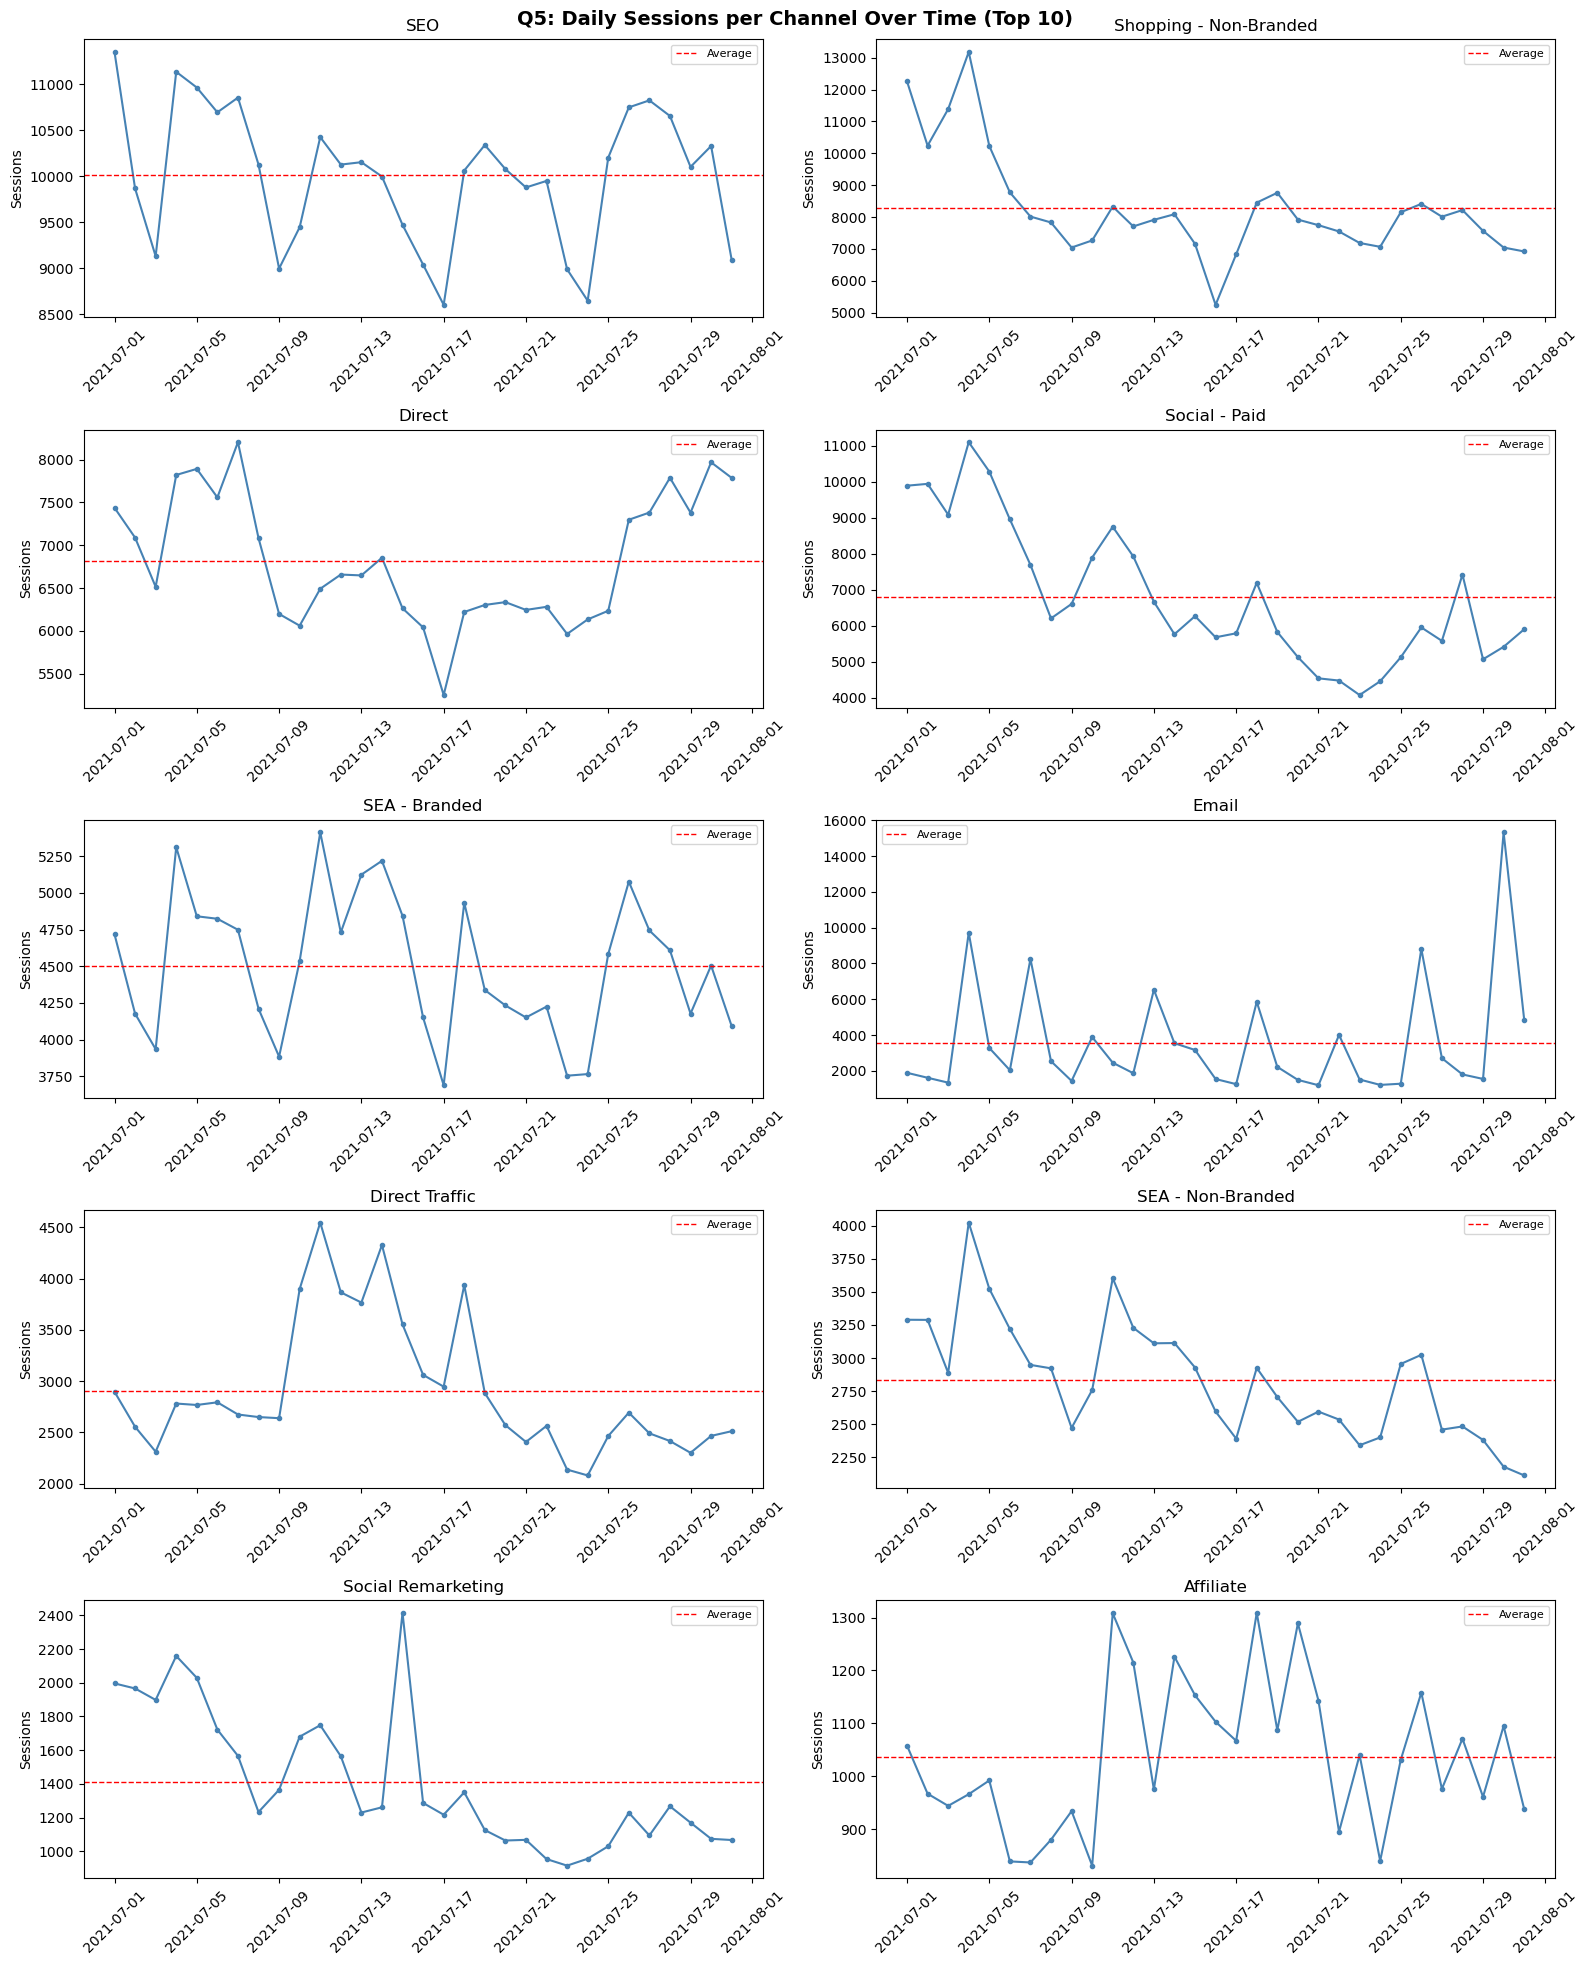

In [26]:
# Q5 Visualisation - Top 10 channels stability
daily_channel = session_sources_clean.groupby(
    ['event_date', 'channel_name'])['session_id'].count().reset_index(
    name='session_count')

top_channels = channel_summary.head(10)['channel_name'].tolist()
daily_top = daily_channel[daily_channel['channel_name'].isin(top_channels)]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, channel in enumerate(top_channels):
    channel_data = daily_top[
        daily_top['channel_name'] == channel].sort_values('event_date')
    axes[i].plot(channel_data['event_date'],
                 channel_data['session_count'],
                 color='steelblue', linewidth=1.5, 
                 marker='o', markersize=3)
    axes[i].axhline(y=channel_data['session_count'].mean(),
                    color='red', linestyle='--', 
                    linewidth=1, label='Average')
    axes[i].set_title(channel)
    axes[i].set_ylabel('Sessions')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=8)

plt.suptitle('Q5: Daily Sessions per Channel Over Time (Top 10)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q5 Findings

**Channel Naming — Data Quality Issue:**

| Metric | Value |
|--------|-------|
| Channel names before standardisation | 28 |
| Channel names after standardisation | 21 |
| Channels merged | 7 naming inconsistencies fixed |

- 'Direct' and 'Direct Traffic' kept separate pending 
  business clarification

**Channel Coverage:**
- 19 out of 21 channels active on all 31 days
- Display Remarketing (2 sessions) and Content Marketing 
  (1 session) — effectively inactive, likely test campaigns

**Campaign ID Tagging — Paid Channels:**

| Channel | Untagged Sessions | Untagged Rate |
|---------|------------------|---------------|
| Social - Paid | 210,498 | 100% |
| SEA (no tagging) | 2,242 | 43.80% |
| Display | 3,196 | 22.69% |
| SEA - Branded | 4,954 | 3.55% |
| SEA - Non-Branded | 2,749 | 3.13% |

- Social - Paid 100% untagged — entire channel invisible 
  at campaign level, ROI unmeasurable
- Organic channels (SEO, Direct, Email etc.) showing zero 
  campaign IDs is expected

**Session Stability:**
- SEO most stable, consistently highest volume (~10,009/day)
- Email shows expected spike pattern on 2021-07-30 consistent 
  with batch send (confirmed in Q2)
- Social - Paid shows highest volatility among top channels
- Shopping - Non-Branded shows slight downward trend over time

**Business Impact:**
- Inconsistent channel naming would split performance metrics 
  across duplicate channel names without standardisation
- Social - Paid campaign level analysis completely impossible 
  until UTM tagging is fixed

## Q6: Any other issues?

### Approach
Identified three additional areas not explicitly covered in Q1-Q5:
1. Market level analysis — revenue consistency across markets
2. CPC analysis — cost per click data quality in session_sources
3. Session to conversion rate — channel efficiency and tracking gaps

### Assumptions
- Base currency is Euro (€) throughout
- Denmark (DK) does not use Euro — Danish Krone (DKK) suspected 
  as root cause of revenue anomaly
- Organic channels (SEO, Direct, Email, Social Organic, Referral, 
  Influencers) are expected to have zero CPC and zero campaign IDs
- Conversion rate calculated as converting sessions / total sessions
  per channel

In [27]:
# Q6a: Market level analysis
market_summary = conversions_clean.groupby('market').agg(
    total_conversions=('conv_id', 'count'),
    total_revenue=('revenue', 'sum'),
    avg_revenue_per_conversion=('revenue', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

market_summary['total_revenue'] = market_summary['total_revenue'].round(2)
market_summary['avg_revenue_per_conversion'] = market_summary[
    'avg_revenue_per_conversion'].round(2)

print("Market level summary:")
display(market_summary)

# Outlier detection
mean_rev = market_summary['avg_revenue_per_conversion'].mean()
std_rev = market_summary['avg_revenue_per_conversion'].std()
outlier_markets = market_summary[
    abs(market_summary['avg_revenue_per_conversion'] - mean_rev) > 2*std_rev]
print(f"\nMarkets with unusual avg revenue per conversion:")
display(outlier_markets)

Market level summary:


,market,total_conversions,total_revenue,avg_revenue_per_conversion
22,NL,4496,230207.86,51.20
12,GB,5760,210834.49,36.60
5,DE,3663,206217.94,56.30
11,FR,1555,67802.85,43.60
6,DK,127,62180.64,489.61
1,BE,628,31638.48,50.38
0,AT,514,28639.29,55.72
16,IE,28,2909.25,103.90
25,SE,18,2095.30,116.41
17,IT,25,2093.52,83.74



Markets with unusual avg revenue per conversion:


,market,total_conversions,total_revenue,avg_revenue_per_conversion
6,DK,127,62180.64,489.61


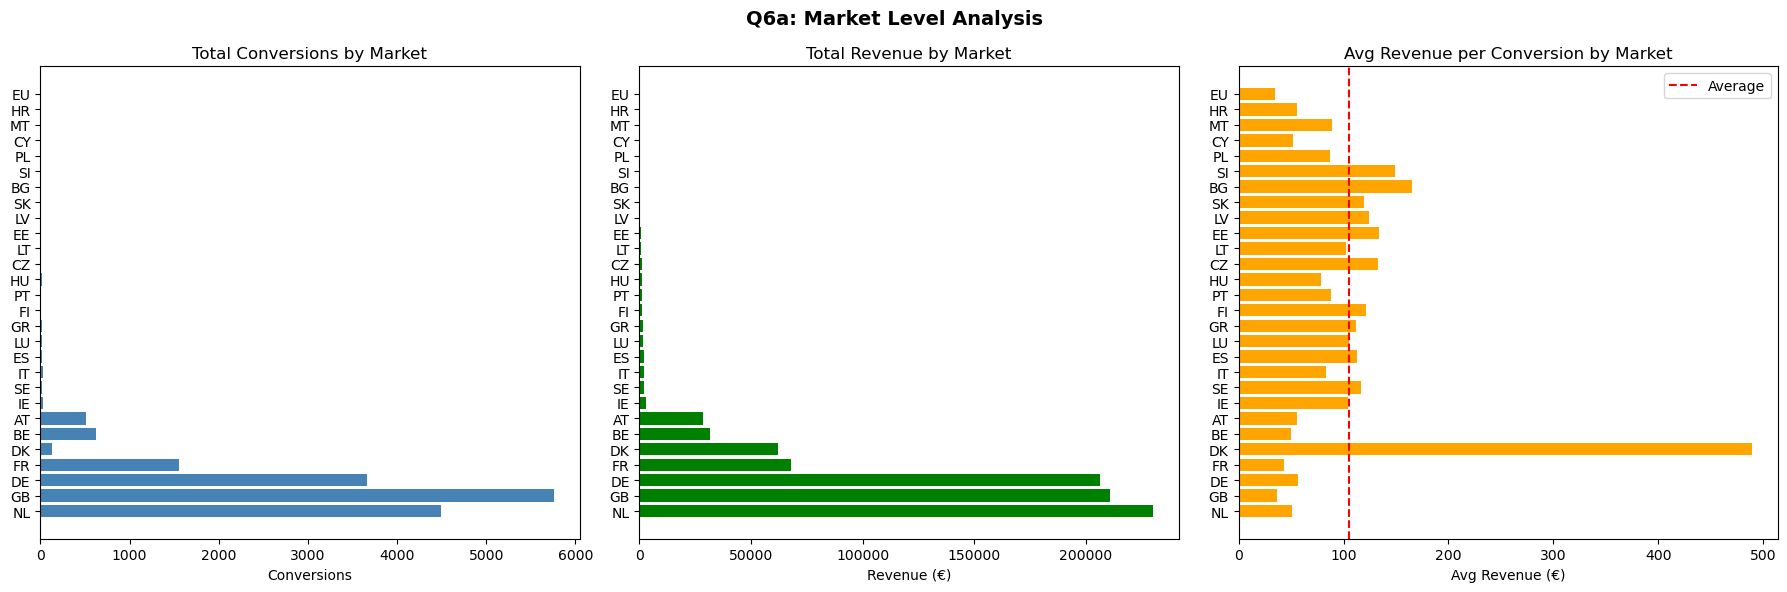

In [28]:
# Q6a Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Total conversions
axes[0].barh(market_summary['market'],
             market_summary['total_conversions'],
             color='steelblue')
axes[0].set_title('Total Conversions by Market')
axes[0].set_xlabel('Conversions')

# Plot 2: Total revenue
axes[1].barh(market_summary['market'],
             market_summary['total_revenue'],
             color='green')
axes[1].set_title('Total Revenue by Market')
axes[1].set_xlabel('Revenue (€)')

# Plot 3: Avg revenue per conversion
axes[2].barh(market_summary['market'],
             market_summary['avg_revenue_per_conversion'],
             color='orange')
axes[2].set_title('Avg Revenue per Conversion by Market')
axes[2].set_xlabel('Avg Revenue (€)')
axes[2].axvline(x=mean_rev, color='red', linestyle='--', label='Average')
axes[2].legend()

plt.suptitle('Q6a: Market Level Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Q6b: CPC analysis
print("CPC value summary:")
print(session_sources_clean['cpc'].describe().round(4))

# Zero CPC on paid channels
paid_channels = ['SEA - Branded', 'SEA - Non-Branded', 'SEA (no tagging)',
                 'Shopping - Branded', 'Shopping - Non-Branded',
                 'Social - Paid', 'Display', 'Google Remarketing',
                 'Video Marketing', 'YouTube Video Ads', 
                 'Social Remarketing']

zero_cpc_paid = session_sources_clean[
    (session_sources_clean['cpc'] == 0) &
    (session_sources_clean['channel_name'].isin(paid_channels))]
print(f"\nZero CPC sessions on paid channels: {len(zero_cpc_paid)}")

# Top campaigns with zero CPC
print(f"\nTop campaigns with zero CPC on paid channels:")
display(zero_cpc_paid['campaign_id'].value_counts().head(10).reset_index())

# campaign_id_79 investigation
camp_79 = session_sources_clean[
    session_sources_clean['campaign_id'] == 'campaign_id_79']
print(f"\ncampaign_id_79 — zero CPC rate: "
      f"{round(len(camp_79[camp_79['cpc']==0])/len(camp_79)*100, 2)}%")
print(f"Channels: {camp_79['channel_name'].value_counts().to_dict()}")

# High CPC outliers
mean_cpc = session_sources_clean[
    session_sources_clean['cpc'] > 0]['cpc'].mean()
std_cpc = session_sources_clean[
    session_sources_clean['cpc'] > 0]['cpc'].std()
high_cpc = session_sources_clean[
    session_sources_clean['cpc'] > mean_cpc + 2*std_cpc]
print(f"\nAverage CPC (positive only): €{round(mean_cpc, 4)}")
print(f"Sessions with unusually high CPC: {len(high_cpc)}")
print(f"Maximum CPC: €{round(session_sources_clean['cpc'].max(), 2)}")
print(f"\nHigh CPC by channel:")
display(high_cpc.groupby('channel_name').agg(
    session_count=('session_id', 'count'),
    avg_cpc=('cpc', 'mean'),
    max_cpc=('cpc', 'max')
).round(4).sort_values('avg_cpc', ascending=False))

CPC value summary:
count    1.616702e+06
mean     4.208000e-01
std      1.057900e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      6.880000e-01
max      4.412500e+02
Name: cpc, dtype: float64

Zero CPC sessions on paid channels: 56988

Top campaigns with zero CPC on paid channels:


,campaign_id,count
0,notset,31689
1,campaign_id_79,20916
2,campaign_id_32,1681
3,campaign_id_45,331
4,campaign_id_91,207
5,campaign_id_52,179
6,campaign_id_60,131
7,campaign_id_81,120
8,campaign_id_124,100
9,campaign_id_34,91



campaign_id_79 — zero CPC rate: 100.0%
Channels: {'Shopping - Non-Branded': 20914, 'SEO': 11, 'SEA - Non-Branded': 2}

Average CPC (positive only): €0.9064
Sessions with unusually high CPC: 7456
Maximum CPC: €441.25

High CPC by channel:


,session_count,avg_cpc,max_cpc
channel_name,,,
Affiliate,11,9.7491,56.770
Social - Paid,1872,8.6124,441.250
YouTube Video Ads,2863,5.5848,22.291
Video Marketing,840,5.2575,17.198
Google Remarketing,460,5.2208,10.000
Social Remarketing,479,4.8235,12.250
SEA - Branded,16,4.7944,7.420
SEA - Non-Branded,853,4.7262,17.740
SEA (no tagging),2,4.4700,4.840


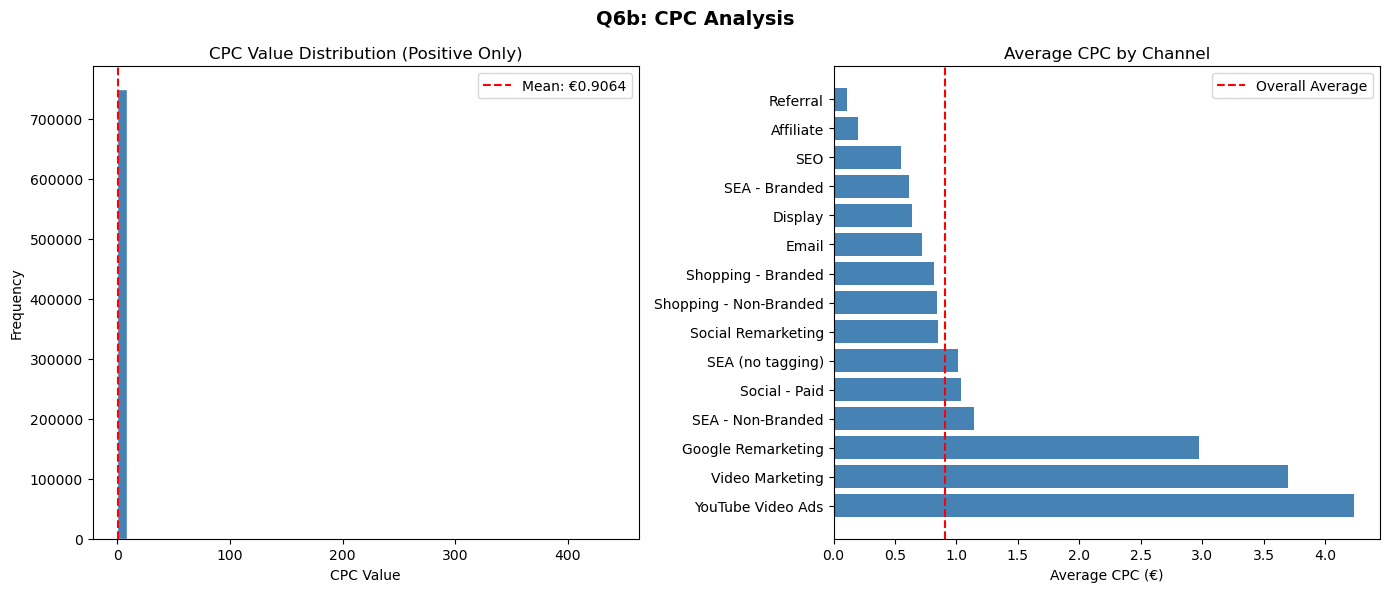

In [30]:
# Q6b Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: CPC distribution
cpc_positive = session_sources_clean[
    session_sources_clean['cpc'] > 0]['cpc']
axes[0].hist(cpc_positive, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('CPC Value Distribution (Positive Only)')
axes[0].set_xlabel('CPC Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=mean_cpc, color='red', linestyle='--',
                label=f'Mean: €{round(mean_cpc, 4)}')
axes[0].legend()

# Plot 2: Average CPC by channel
cpc_by_channel = session_sources_clean[
    session_sources_clean['cpc'] > 0].groupby(
    'channel_name')['cpc'].mean().round(4).sort_values(
    ascending=False).reset_index()
axes[1].barh(cpc_by_channel['channel_name'],
             cpc_by_channel['cpc'], color='steelblue')
axes[1].set_title('Average CPC by Channel')
axes[1].set_xlabel('Average CPC (€)')
axes[1].axvline(x=mean_cpc, color='red', linestyle='--', 
                label='Overall Average')
axes[1].legend()

plt.suptitle('Q6b: CPC Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Q6c: Session to conversion rate by channel

# Total sessions per channel
total_sessions_by_channel = session_sources_clean.groupby(
    'channel_name')['session_id'].nunique().reset_index(
    name='total_sessions')

# Converting sessions
converting_sessions = attribution_clean.merge(
    session_sources_clean[['session_id', 'channel_name']],
    on='session_id', how='left')
converting_by_channel = converting_sessions.groupby(
    'channel_name')['session_id'].nunique().reset_index(
    name='converting_sessions')

# Merge and calculate
channel_conversion = total_sessions_by_channel.merge(
    converting_by_channel, on='channel_name', how='left')
channel_conversion['converting_sessions'] = channel_conversion[
    'converting_sessions'].fillna(0)
channel_conversion['conversion_rate_%'] = round(
    channel_conversion['converting_sessions'] / 
    channel_conversion['total_sessions'] * 100, 2)
channel_conversion = channel_conversion.sort_values(
    'conversion_rate_%', ascending=False)

mean_cr = channel_conversion['conversion_rate_%'].mean()
print(f"Overall average conversion rate: {round(mean_cr, 2)}%")
print(f"Non-converting session rate: "
      f"{round((1 - channel_conversion['converting_sessions'].sum() / channel_conversion['total_sessions'].sum()) * 100, 2)}%")
display(channel_conversion)

Overall average conversion rate: 1.09%
Non-converting session rate: 98.68%


,channel_name,total_sessions,converting_sessions,conversion_rate_%
11,SEA - Branded,139546,3573.0,2.56
9,Referral,24575,603.0,2.45
6,Email,110181,2546.0,2.31
0,Affiliate,32128,692.0,2.15
14,Shopping - Branded,27344,439.0,1.61
2,Direct,211362,3152.0,1.49
3,Direct Traffic,89945,1267.0,1.41
15,Shopping - Non-Branded,256499,3242.0,1.26
16,Social - Organic,29867,367.0,1.23
13,SEO,310277,2991.0,0.96


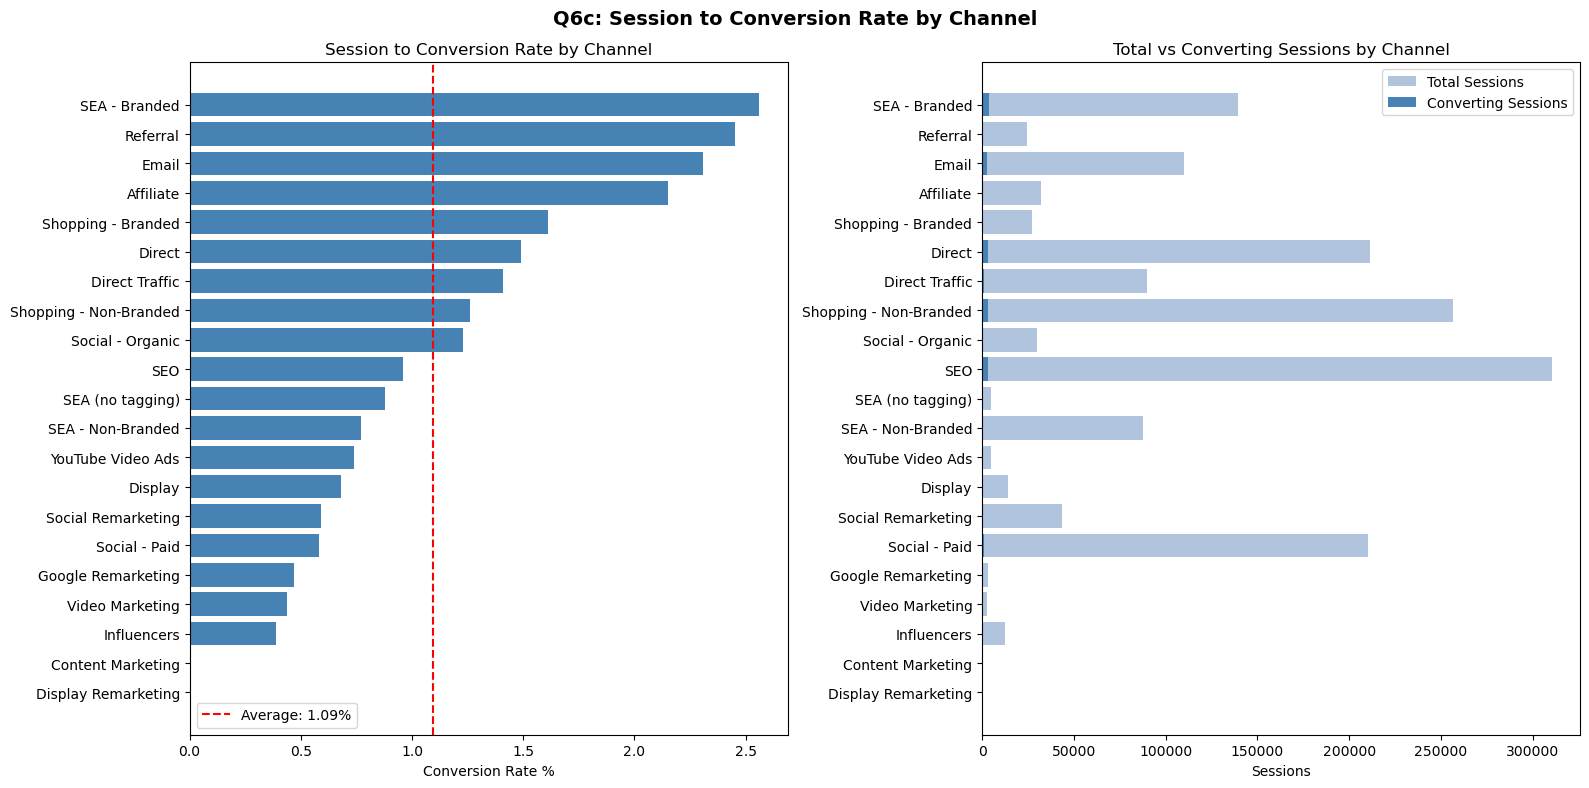

In [32]:
# Q6c Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

channel_conversion_sorted = channel_conversion.sort_values('conversion_rate_%')

# Plot 1: Conversion rate
axes[0].barh(channel_conversion_sorted['channel_name'],
             channel_conversion_sorted['conversion_rate_%'],
             color='steelblue')
axes[0].set_title('Session to Conversion Rate by Channel')
axes[0].set_xlabel('Conversion Rate %')
axes[0].axvline(x=mean_cr, color='red', linestyle='--',
                label=f'Average: {round(mean_cr, 2)}%')
axes[0].legend()

# Plot 2: Total vs converting sessions
axes[1].barh(channel_conversion_sorted['channel_name'],
             channel_conversion_sorted['total_sessions'],
             color='lightsteelblue', label='Total Sessions')
axes[1].barh(channel_conversion_sorted['channel_name'],
             channel_conversion_sorted['converting_sessions'],
             color='steelblue', label='Converting Sessions')
axes[1].set_title('Total vs Converting Sessions by Channel')
axes[1].set_xlabel('Sessions')
axes[1].legend()

plt.suptitle('Q6c: Session to Conversion Rate by Channel',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q6 Findings

**Q6a: Market Level Analysis**

| Metric | Value |
|--------|-------|
| Markets analysed | 28 |
| Top 3 markets by revenue | NL, GB, DE |
| Markets with < 30 conversions | 18 |
| Outlier market | DK — €489.61 avg revenue vs €100 overall |

- **DK Currency Issue:** Denmark uses DKK not EUR. €489.61 avg 
  revenue per conversion is ~5x overall average, consistent with 
  DKK values not being converted to EUR
- True DK revenue likely ~€8,291 vs reported €62,180
- 18 low volume markets — results statistically unreliable

---

**Q6b: CPC Analysis**

| Issue | Finding |
|-------|---------|
| Zero CPC on paid channels | 56,988 sessions |
| notset campaign | 31,689 zero CPC sessions (55.6%) |
| campaign_id_79 | 20,927 sessions, 100% zero CPC |
| High CPC outlier | €441.25 max in Social - Paid |
| Sessions beyond 2 std CPC | 7,456 |

- notset and campaign_id_79 account for 92% of zero CPC paid sessions
- €441.25 CPC in Social - Paid is 487x average — likely data entry error
- Zero CPC on paid channels makes true ROI calculations unreliable

---

**Q6c: Session to Conversion Rate**

| Channel | Conversion Rate | vs Average |
|---------|----------------|------------|
| SEA - Branded | 2.56% | +135% |
| Referral | 2.45% | +125% |
| Email | 2.31% | +112% |
| Affiliate | 2.15% | +97% |
| Social - Paid | 0.58% | -47% |
| Video Marketing | 0.44% | -60% |
| Influencers | 0.39% | -64% |

- Overall average: 1.09%, non-converting rate: 98.68% (industry normal)
- All attributed sessions have matching session_source records
- **Social - Paid most concerning:** 4th largest channel, below 
  average conversion (0.58%), 100% untagged campaign IDs — 
  performance and tracking issues combined
- SEA - Branded delivers 4x better conversion than Social - Paid 
  despite lower volume

# Executive Summary

## Data Quality Issues Found & Resolved

| # | Issue | Table | Finding | Action |
|---|-------|-------|---------|--------|
| 1 | Duplicate conv_ids | conversions | 16 duplicates, different values | Replaced with backend values |
| 2 | Missing conversions | conversions vs backend | 345 conv_ids missing from conversions | Flagged as pipeline issue |
| 3 | Revenue mismatch | conversions vs backend | 172 records, €9,868.27 discrepancy | Corrected using backend values |
| 4 | Zero/negative revenue | conversions | 197 records | Separated as potential refunds |
| 5 | Zero/negative revenue | conversions_backend | 27 records | Separated as potential refunds |
| 6 | Zero clicks, positive cost | api_adwords_costs | 10 records, 3 campaigns | Flagged — impossible in normal ad serving |
| 7 | Orphan conv_ids | attribution_customer_journey | 392 records | Removed — unverifiable conversions |
| 8 | IHC violations | attribution_customer_journey | 158 conv_ids (2.26%) | Flagged with ihc_flag column |
| 9 | Inconsistent channel names | session_sources | 28 names → 21 | Standardised using mapping |
| 10 | Zero CPC on paid channels | session_sources | 56,988 sessions | Flagged — missing cost data |
| 11 | High CPC outlier | session_sources | €441.25 max CPC | Flagged — likely data entry error |
| 12 | DK currency mismatch | conversions | €489.61 avg vs €100 overall | Flagged — likely recorded in DKK |
| 13 | Untagged campaign IDs | session_sources | Social - Paid 100% untagged | Flagged — systematic tracking failure |

---

## Business Questions Summary

### Q1: Cost Coverage
- 9 out of 109 campaigns have costs with no matching sessions
- Total unmatched spend: €472.88
- 5 campaigns with 0% coverage — €1,064.06 completely unattributable
- campaign_id_94, campaign_id_7, campaign_id_156 have compounding 
  issues — 0% coverage AND zero clicks with positive cost

### Q2: Conversion Stability
- Clear upward weekly trend (3,900 → 5,400 → 7,500 conversions)
- One anomalous day: 2021-07-30 — confirmed genuine business event
  driven by large email campaign (Email sessions 4.85x normal)
- 17 days of data — insufficient for seasonality conclusions

### Q3: Backend Verification
- 16 duplicate conv_ids, 172 revenue mismatches (€9,868.27), 
  345 missing records — all resolved using backend as source of truth
- Raw conversions table understates revenue by €9,868.27

### Q4: Attribution Consistency
- 97.74% of conversions have valid IHC values
- 158 violations (2.26%) — all under-attributed
- 33 single session ihc violations are downstream effect of 
  orphan removal — will resolve after pipeline fix
- conv_id_4487 extreme journey (91 sessions) assessed as genuine

### Q5: Channel Stability
- 28 channel names standardised to 21
- 19 out of 21 channels active on all 31 days
- Social - Paid 100% untagged — ROI completely unmeasurable
- Email spike on 2021-07-30 consistent with Q2 findings

### Q6: Additional Issues
- DK avg revenue €489.61 vs €100 overall — likely DKK not EUR,
  true value ~€8,291 vs reported €62,180
- 56,988 zero CPC sessions on paid channels — 92% from notset 
  and campaign_id_79 (100% zero CPC)
- SEA - Branded highest conversion rate (2.56%), Influencers 
  lowest (0.39%), Social - Paid underperforms despite high volume

---

## Priority Recommendations

| Priority | Action | Impact |
|----------|--------|--------|
| 1 | Fix pipeline — 345 conversions missing from conversions table | Revenue underreported, conversions missing |
| 2 | Investigate campaign_id_97, campaign_id_121 | €429.31 unmatched spend |
| 3 | Investigate campaign_id_94, campaign_id_7, campaign_id_156 | €634.75 unattributable, possible billing issue |
| 4 | Fix UTM tagging for Social - Paid | 4th largest channel invisible at campaign level |
| 5 | Confirm DK revenue currency | €53,889 potential revenue overstatement |
| 6 | Audit campaign_id_79 CPC tracking | 20,927 sessions with unknown cost |
| 7 | Standardise channel naming across tracking systems | Prevents future splitting of channel metrics |
| 8 | Re-run attribution model after pipeline fixes | IHC violations will self-resolve |

---

## Clean Datasets Produced

| Dataset | Description |
|---------|-------------|
| conversions_clean | Duplicates resolved, revenue corrected using backend |
| conversions_valid | Additionally excludes zero/negative revenue |
| conversions_backend_valid | Backend records with positive revenue only |
| api_costs_valid | Excludes zero/negative click records |
| attribution_clean | Orphans removed, IHC violations flagged |
| session_sources_clean | Channel names standardised |